# Phase 3: Architecture Search with RL Training (Optimized)

## Optimizations over the original notebook
| Area | Original | Optimized |
|------|----------|-----------|
| Hardware | CPU only | Auto-detect GPU / CPU |
| Batch forward | 64 separate `forward()` calls | 1 `forward_batch()` call (grouped by task) |
| Loss computation | Accumulated in a Python loop | Single `MSELoss` on full batch tensor |
| Replay buffer | Per-sample tensor ops | Batch `stack` + single `.to(device)` |

## Ground Truth
- Task 1: uses **b1** and **b2**
- Task 2: uses **b3**
- Task 3: uses **b1** and **b4**

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from typing import Dict, List
from collections import deque
import random
from tqdm import tqdm
import itertools
import os

# Device configuration: use GPU if available, otherwise CPU
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"[Device] Using: {DEVICE}")

np.random.seed(42)
torch.manual_seed(42)
random.seed(42)

print("[OK] All libraries imported successfully")

[Device] Using: cuda
[OK] All libraries imported successfully


## 1. RL Environment

In [2]:
class RLEnvironment:
    """RL Environment: Contextual Bandit setup."""

    def __init__(self):
        self.tasks = ['task1', 'task2', 'task3']
        self.current_state = None

    def reset(self):
        """Sample a new state and return it as a CPU tensor."""
        self.current_state = {
            'b1': np.random.uniform(-1, 1),
            'b2': np.random.uniform(0, 2 * np.pi),
            'b3': np.random.randint(0, 2),
            'b4': np.random.uniform(-1, 1, size=2)
        }
        return self.state_to_tensor(self.current_state)

    def step(self, task_name: str):
        """Return the reward for the given task on the current state."""
        reward = self.compute_reward(self.current_state, task_name)
        return reward, True

    def compute_reward(self, state, task):
        """Ground truth reward functions."""
        if task == 'task1':
            return state['b1'] + np.sin(state['b2'])
        elif task == 'task2':
            return 2 * state['b3'] - 1
        elif task == 'task3':
            return state['b1'] + np.linalg.norm(state['b4'])

    def state_to_tensor(self, state):
        """Convert state dict to a float32 CPU tensor (moved to GPU on demand)."""
        return torch.tensor([
            state['b1'], state['b2'], float(state['b3']),
            state['b4'][0], state['b4'][1]
        ], dtype=torch.float32)


env = RLEnvironment()
print("[OK] RL Environment created")

[OK] RL Environment created


## 2. Replay Buffer

**Optimization:** States are stored as CPU tensors and rewards as plain floats.
When sampling, a single `torch.stack` + `.to(DEVICE)` moves the entire batch to GPU at once,
avoiding repeated per-sample device transfers.

In [3]:
class ReplayBuffer:
    """Experience replay buffer.

    Stores (state, task, reward) tuples on CPU.
    Batch transfers to the target device happen once per sample call.
    """

    def __init__(self, capacity=10000):
        self.buffer = deque(maxlen=capacity)

    def push(self, state, task, reward):
        # Store reward as a plain float to minimize memory overhead
        self.buffer.append((state, task, float(reward)))

    def sample(self, batch_size):
        batch = random.sample(self.buffer, batch_size)
        states, tasks, rewards = zip(*batch)
        # Single stack + device transfer for the whole batch
        states_t  = torch.stack(states).to(DEVICE)
        rewards_t = torch.tensor(rewards, dtype=torch.float32, device=DEVICE)
        return states_t, list(tasks), rewards_t

    def __len__(self):
        return len(self.buffer)


print("[OK] ReplayBuffer defined")

[OK] ReplayBuffer defined


## 3. Modular Q-Network

### Key optimization: `forward_batch`

The original code called `forward()` **64 times** per update step (once per sample in the batch).

`forward_batch` groups samples by task and runs each group through its head in one matrix
operation, reducing 64 forward passes to at most **3** (one per unique task).

```
Original:  for i in range(64): model(state_i, task_i)   → 64 forward passes
Optimized: model.forward_batch(states, tasks)            → 3 forward passes
```

In [4]:
class BlockModule(nn.Module):
    """Small MLP for a single state block."""

    def __init__(self, input_dim, hidden_dim=16, output_dim=8):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, output_dim)
        )

    def forward(self, x):
        return self.net(x)


class ModularQNetwork(nn.Module):
    """Modular Q-Network with GPU support and batched forward pass."""

    def __init__(self, architecture, module_output_dim=8):
        super().__init__()
        self.architecture = architecture

        # 4 block modules: b1(1-dim), b2(1-dim), b3(1-dim), b4(2-dim)
        self.block_modules = nn.ModuleList([
            BlockModule(1, hidden_dim=16, output_dim=module_output_dim),
            BlockModule(1, hidden_dim=16, output_dim=module_output_dim),
            BlockModule(1, hidden_dim=16, output_dim=module_output_dim),
            BlockModule(2, hidden_dim=16, output_dim=module_output_dim),
        ])

        # One linear head per task: concat(selected blocks) -> scalar Q-value
        self.heads = nn.ModuleDict()
        for task_name, block_indices in architecture.items():
            input_dim = len(block_indices) * module_output_dim
            self.heads[task_name] = nn.Linear(input_dim, 1)

    def extract_blocks(self, x):
        """Split the 5-dim state tensor into 4 block slices."""
        if x.dim() == 1:
            x = x.unsqueeze(0)
        return [x[:, 0:1], x[:, 1:2], x[:, 2:3], x[:, 3:5]]

    def forward(self, x, task_name=None):
        """Single-sample or small-batch inference (used during evaluation)."""
        blocks = self.extract_blocks(x)
        module_outputs = [m(b) for m, b in zip(self.block_modules, blocks)]

        if task_name is not None:
            idx = self.architecture[task_name]
            h = torch.cat([module_outputs[i] for i in idx], dim=1)
            return self.heads[task_name](h).squeeze(-1)
        else:
            return {
                t: self.heads[t](
                    torch.cat([module_outputs[i] for i in idx], dim=1)
                ).squeeze(-1)
                for t, idx in self.architecture.items()
            }

    def forward_batch(self, states: torch.Tensor, tasks: List[str]) -> torch.Tensor:
        """Batched forward pass grouped by task.

        Instead of calling forward() once per sample, samples are grouped by
        task and each group is processed in a single matrix operation.
        Reduces 64 forward passes to at most 3.
        """
        blocks = self.extract_blocks(states)                                    # 4 x (B, dim)
        module_outputs = [m(b) for m, b in zip(self.block_modules, blocks)]    # 4 x (B, 8)

        pred_qs = torch.empty(len(tasks), device=states.device)

        # Group sample indices by task
        task_indices: Dict[str, List[int]] = {}
        for i, t in enumerate(tasks):
            task_indices.setdefault(t, []).append(i)

        # One head call per unique task
        for t, indices in task_indices.items():
            idx_t = torch.tensor(indices, device=states.device)
            block_idx = self.architecture[t]
            h = torch.cat([module_outputs[j][idx_t] for j in block_idx], dim=1)
            pred_qs[idx_t] = self.heads[t](h).squeeze(-1)

        return pred_qs


print("[OK] ModularQNetwork defined")

[OK] ModularQNetwork defined


## 4. RL Training Function

**Optimizations:**
1. Model runs on `DEVICE` (GPU if available)
2. `forward_batch` replaces the per-sample loop — batch processed in 3 matrix ops
3. `MSELoss` computed over the full batch tensor in one call

In [5]:
def train_with_rl(model: ModularQNetwork, env: RLEnvironment,
                  n_episodes=1000, batch_size=64, lr=1e-3, verbose=False):
    """Train model with TD Learning + Experience Replay.

    Since this is a Contextual Bandit (single-step MDP), the TD target
    equals the immediate reward: target_q = reward (no gamma * Q(s')).
    """
    model.to(DEVICE)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()
    replay_buffer = ReplayBuffer(capacity=10000)

    episode_rewards = {task: [] for task in env.tasks}
    losses = []

    pbar = tqdm(range(n_episodes), desc="RL Training", disable=not verbose)

    for episode in pbar:
        # --- Interaction phase ---
        state = env.reset()   # CPU tensor
        for task in env.tasks:
            reward, _ = env.step(task)
            replay_buffer.push(state.clone(), task, reward)
            episode_rewards[task].append(reward)

        # --- Learning phase ---
        if len(replay_buffer) >= batch_size:
            batch_states, batch_tasks, batch_rewards = replay_buffer.sample(batch_size)
            # batch_states:  (64, 5) on DEVICE
            # batch_rewards: (64,)   on DEVICE

            model.train()
            optimizer.zero_grad()

            # Batched forward: 3 matrix ops instead of 64 separate forwards
            pred_qs = model.forward_batch(batch_states, batch_tasks)  # (64,)
            loss = criterion(pred_qs, batch_rewards)

            loss.backward()
            optimizer.step()

            losses.append(loss.item())
            if verbose:
                pbar.set_postfix({'loss': f'{losses[-1]:.4f}'})

    pbar.close()

    avg_rewards = {t: np.mean(r[-100:]) for t, r in episode_rewards.items()}
    return {
        'episode_rewards': episode_rewards,
        'losses': losses,
        'avg_rewards': avg_rewards
    }


print("[OK] RL training function defined")

[OK] RL training function defined


## 5. Architecture Search Space

Enumerates all possible block combinations for each task and takes their Cartesian product.

- Each task can use 1 or 2 blocks out of 4 → **10** combinations per task
- 3 tasks → **10 × 10 × 10 = 1000** total architectures

In [6]:
class ArchitectureSpace:
    """Defines and manages the full architecture search space."""

    def __init__(self, n_blocks=4, tasks=None, max_blocks_per_task=2):
        self.n_blocks = n_blocks
        self.tasks = tasks if tasks else ['task1', 'task2', 'task3']
        self.max_blocks_per_task = max_blocks_per_task
        self.all_architectures = self._generate_all_architectures()

    def _generate_single_task_architectures(self):
        """All block subsets of size 1..max_blocks_per_task for one task."""
        archs = []
        for size in range(1, self.max_blocks_per_task + 1):
            for combo in itertools.combinations(range(self.n_blocks), size):
                archs.append(list(combo))
        return archs

    def _generate_all_architectures(self):
        """Cartesian product of single-task architectures across all tasks."""
        single = self._generate_single_task_architectures()
        return [
            {self.tasks[i]: combo[i] for i in range(len(self.tasks))}
            for combo in itertools.product(single, repeat=len(self.tasks))
        ]

    def sample_random_architecture(self):
        """Randomly sample one architecture from the full space."""
        return self.all_architectures[np.random.randint(len(self.all_architectures))]

    def architecture_to_string(self, arch):
        """Human-readable string representation of an architecture."""
        parts = []
        for task in self.tasks:
            names = [['b1', 'b2', 'b3', 'b4'][i] for i in arch[task]]
            parts.append(f"{task}:{','.join(names)}")
        return " | ".join(parts)

    def is_correct_architecture(self, arch):
        """Check whether the architecture matches the ground truth."""
        gt = {'task1': [0, 1], 'task2': [2], 'task3': [0, 3]}
        return all(set(arch[t]) == set(gt[t]) for t in self.tasks)


arch_space = ArchitectureSpace(n_blocks=4, max_blocks_per_task=2)
print(f"[OK] Architecture Search Space created")
print(f"     Total architectures: {len(arch_space.all_architectures)}")

gt_arch = {'task1': [0, 1], 'task2': [2], 'task3': [0, 3]}
print(f"\nGround Truth Architecture:")
print(f"     {arch_space.architecture_to_string(gt_arch)}")

[OK] Architecture Search Space created
     Total architectures: 1000

Ground Truth Architecture:
     task1:b1,b2 | task2:b3 | task3:b1,b4


## 6. Architecture Evaluation Function

Trains a fresh model for a given architecture, then evaluates its prediction accuracy
over 100 held-out episodes and returns the average MSE.

In [7]:
def evaluate_architecture_rl(architecture, env, n_episodes=1000,
                              n_eval_episodes=100, verbose=False):
    """Train a model with the given architecture and return its evaluation MSE.

    Returns
    -------
    avg_mse : float
        Mean squared error averaged over n_eval_episodes and all tasks.
    history : dict
        Training history (losses, episode rewards).
    """
    # Train
    model = ModularQNetwork(architecture).to(DEVICE)
    history = train_with_rl(model, env, n_episodes=n_episodes, verbose=verbose)

    # Evaluate
    model.eval()
    eval_mses = []
    with torch.no_grad():
        for _ in range(n_eval_episodes):
            state = env.reset().to(DEVICE)
            task_mses = []
            for task in env.tasks:
                true_reward, _ = env.step(task)
                pred_q = model(state, task_name=task).item()
                task_mses.append((pred_q - true_reward) ** 2)
            eval_mses.append(np.mean(task_mses))

    return np.mean(eval_mses), history


print("[OK] Architecture evaluation function defined")

[OK] Architecture evaluation function defined


## 6b. Pre-compute All Architectures

Train and evaluate every architecture once, storing results in a lookup dict.
Subsequent search algorithms query this dict instead of re-training, making
random search and exhaustive search nearly instantaneous.

In [8]:
def precompute_all_architectures(arch_space, env, n_episodes=1000,
                                  n_eval_episodes=100, verbose_each=False):
    """Pre-train and evaluate ALL architectures. Returns a lookup dict keyed by arch_string."""
    total = len(arch_space.all_architectures)
    print("=" * 80)
    print(f"Pre-computing ALL {total} architectures ({n_episodes} episodes each)")
    print("=" * 80)

    precomputed = {}
    pbar = tqdm(enumerate(arch_space.all_architectures), total=total,
                desc="Pre-computing", unit="arch")

    for idx, arch in pbar:
        arch_string = arch_space.architecture_to_string(arch)
        mse, _ = evaluate_architecture_rl(arch, env,
                                          n_episodes=n_episodes,
                                          n_eval_episodes=n_eval_episodes,
                                          verbose=verbose_each)
        is_correct = arch_space.is_correct_architecture(arch)
        precomputed[arch_string] = {'mse': mse, 'is_correct': is_correct, 'arch': arch}

        best = min(v['mse'] for v in precomputed.values())
        pbar.set_postfix({'cur_mse': f'{mse:.4f}', 'best': f'{best:.4f}', 'GT': is_correct})

    pbar.close()
    best_key = min(precomputed, key=lambda k: precomputed[k]['mse'])
    print(f"\n[OK] Pre-computation done. Total: {len(precomputed)} architectures")
    print(f"     Global best MSE: {precomputed[best_key]['mse']:.6f}")
    print(f"       -> {best_key}")
    return precomputed


print("[OK] precompute_all_architectures defined")

[OK] precompute_all_architectures defined


## 7. Random Search

Randomly sample `n_trials` architectures and find the one with the lowest MSE.
When `precomputed` is provided, results are looked up instantly from the dict.

In [9]:
def random_search(arch_space, env, n_trials=20, n_episodes_per_arch=1000,
                  precomputed=None):
    """Random architecture search.

    If precomputed is provided, MSE is looked up from the dict (fast, deterministic).
    """
    mode = "lookup" if precomputed else "on-the-fly RL"
    print("=" * 80)
    print(f"Random Search: {n_trials} trials  [mode: {mode}]")
    print("=" * 80)

    best_arch, best_mse = None, float('inf')
    history = []

    for trial in tqdm(range(n_trials), desc="Random Search"):
        arch = arch_space.sample_random_architecture()
        arch_string = arch_space.architecture_to_string(arch)

        if precomputed:
            mse = precomputed[arch_string]['mse']
            is_correct = precomputed[arch_string]['is_correct']
        else:
            mse, _ = evaluate_architecture_rl(arch, env, n_episodes=n_episodes_per_arch)
            is_correct = arch_space.is_correct_architecture(arch)

        history.append({'trial': trial + 1, 'architecture': arch,
                        'arch_string': arch_string, 'mse': mse, 'is_correct': is_correct})

        if mse < best_mse:
            best_mse, best_arch = mse, arch
            print(f"\n  Trial {trial+1}: New best MSE={mse:.6f}  {arch_string}")

    return {'history': history, 'best_architecture': best_arch,
            'best_mse': best_mse, 'found_correct': arch_space.is_correct_architecture(best_arch)}


print("[OK] Random search function defined")

[OK] Random search function defined


## 8. Exhaustive Search

Evaluate every architecture in order. Guaranteed to find the global optimum
within the evaluated set.

In [10]:
def exhaustive_search(arch_space, env, n_episodes_per_arch=1000,
                      max_architectures=50, precomputed=None):
    """Exhaustive architecture search.

    If precomputed is provided, MSE is looked up from the dict.
    """
    all_archs = arch_space.all_architectures[:max_architectures]
    mode = "lookup" if precomputed else "on-the-fly RL"
    print("=" * 80)
    print(f"Exhaustive Search: {len(all_archs)} architectures  [mode: {mode}]")
    print("=" * 80)

    best_arch, best_mse = None, float('inf')
    history = []

    for i, arch in enumerate(tqdm(all_archs, desc="Exhaustive Search")):
        arch_string = arch_space.architecture_to_string(arch)

        if precomputed:
            mse = precomputed[arch_string]['mse']
            is_correct = precomputed[arch_string]['is_correct']
        else:
            mse, _ = evaluate_architecture_rl(arch, env, n_episodes=n_episodes_per_arch)
            is_correct = arch_space.is_correct_architecture(arch)

        history.append({'trial': i + 1, 'architecture': arch,
                        'arch_string': arch_string, 'mse': mse, 'is_correct': is_correct})

        if mse < best_mse:
            best_mse, best_arch = mse, arch

    return {'history': history, 'best_architecture': best_arch,
            'best_mse': best_mse, 'found_correct': arch_space.is_correct_architecture(best_arch)}


print("[OK] Exhaustive search function defined")

[OK] Exhaustive search function defined


## 9. Run Architecture Search

### Step 1: Test the ground truth architecture
### Step 2: Pre-compute all 1000 architectures (run once)
### Step 3: Run search using the lookup dict (fast)

In [11]:
# Test the ground truth architecture first
print("=" * 80)
print("Testing Ground Truth Architecture")
print("=" * 80)

gt_arch = {'task1': [0, 1], 'task2': [2], 'task3': [0, 3]}
print(f"\nArchitecture: {arch_space.architecture_to_string(gt_arch)}")

gt_mse, gt_history = evaluate_architecture_rl(
    gt_arch, env,
    n_episodes=1000,
    verbose=True
)

print(f"\nGround Truth MSE: {gt_mse:.6f}")

Testing Ground Truth Architecture

Architecture: task1:b1,b2 | task2:b3 | task3:b1,b4


RL Training: 100%|██████████| 1000/1000 [00:06<00:00, 164.82it/s, loss=0.0429]



Ground Truth MSE: 0.044782


In [12]:
# Step 2: Pre-compute ALL 1000 architectures (run once, results reused by search)
precomputed_results = precompute_all_architectures(
    arch_space, env,
    n_episodes=1000,
    n_eval_episodes=100,
    verbose_each=False
)

Pre-computing ALL 1000 architectures (1000 episodes each)


Pre-computing: 100%|██████████| 1000/1000 [1:11:46<00:00,  4.31s/arch, cur_mse=0.4573, best=0.0253, GT=0]


[OK] Pre-computation done. Total: 1000 architectures
     Global best MSE: 0.025266
       -> task1:b1,b2 | task2:b3 | task3:b1,b4


In [13]:
# Step 3a: Random Search using pre-computed lookup
random_results = random_search(
    arch_space, env,
    n_trials=100,
    precomputed=precomputed_results
)

print(f"\n" + "=" * 80)
print("Random Search Results")
print("=" * 80)
print(f"\nBest Architecture:")
print(f"  {arch_space.architecture_to_string(random_results['best_architecture'])}")
print(f"  MSE: {random_results['best_mse']:.6f}")
print(f"  Is Ground Truth: {random_results['found_correct']}")
print(f"\nGround Truth Architecture:")
print(f"  {arch_space.architecture_to_string(gt_arch)}")
print(f"  MSE: {gt_mse:.6f}")

Random Search: 100 trials  [mode: lookup]


Random Search: 100%|██████████| 100/100 [00:00<?, ?it/s]


  Trial 1: New best MSE=0.608720  task1:b2,b4 | task2:b4 | task3:b4

  Trial 2: New best MSE=0.536823  task1:b2,b3 | task2:b2 | task3:b1,b3

  Trial 3: New best MSE=0.214580  task1:b1,b4 | task2:b3 | task3:b1,b3

  Trial 14: New best MSE=0.138666  task1:b2 | task2:b1,b3 | task3:b1,b4

  Trial 51: New best MSE=0.066908  task1:b1,b2 | task2:b3,b4 | task3:b1,b3

Random Search Results

Best Architecture:
  task1:b1,b2 | task2:b3,b4 | task3:b1,b3
  MSE: 0.066908
  Is Ground Truth: False

Ground Truth Architecture:
  task1:b1,b2 | task2:b3 | task3:b1,b4
  MSE: 0.044782


In [14]:
# Step 3b: Exhaustive Search using pre-computed lookup (all 1000)
exhaustive_results = exhaustive_search(
    arch_space, env,
    max_architectures=1000,
    precomputed=precomputed_results
)

print(f"\n" + "=" * 80)
print("Exhaustive Search Results")
print("=" * 80)
print(f"\nBest Architecture:")
print(f"  {arch_space.architecture_to_string(exhaustive_results['best_architecture'])}")
print(f"  MSE: {exhaustive_results['best_mse']:.6f}")
print(f"  Is Ground Truth: {exhaustive_results['found_correct']}")

Exhaustive Search: 1000 architectures  [mode: lookup]


Exhaustive Search: 100%|██████████| 1000/1000 [00:00<00:00, 333383.99it/s]


Exhaustive Search Results

Best Architecture:
  task1:b1,b2 | task2:b3 | task3:b1,b4
  MSE: 0.025266
  Is Ground Truth: True


## 10. Visualize Results

[OK] Saved: results_diagram/phase3_search_results.png


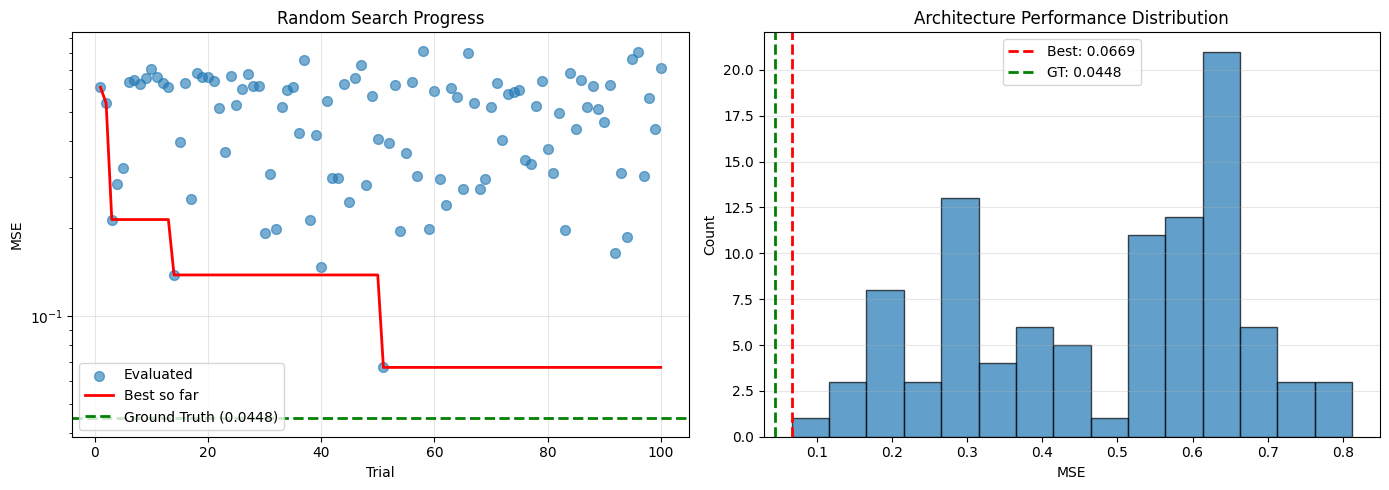

In [15]:
os.makedirs('results_diagram', exist_ok=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: random search progress
ax = axes[0]
mses = [h['mse'] for h in random_results['history']]
best_so_far = [min(mses[:i+1]) for i in range(len(mses))]

ax.scatter(range(1, len(mses)+1), mses, alpha=0.6, s=50, label='Evaluated')
ax.plot(range(1, len(best_so_far)+1), best_so_far, 'r-', lw=2, label='Best so far')
ax.axhline(gt_mse, color='g', ls='--', lw=2, label=f'Ground Truth ({gt_mse:.4f})')
ax.set_xlabel('Trial')
ax.set_ylabel('MSE')
ax.set_title('Random Search Progress')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_yscale('log')

# Right: MSE distribution
ax = axes[1]
ax.hist(mses, bins=15, alpha=0.7, edgecolor='black')
ax.axvline(random_results['best_mse'], color='r', ls='--', lw=2,
           label=f"Best: {random_results['best_mse']:.4f}")
ax.axvline(gt_mse, color='g', ls='--', lw=2, label=f"GT: {gt_mse:.4f}")
ax.set_xlabel('MSE')
ax.set_ylabel('Count')
ax.set_title('Architecture Performance Distribution')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('results_diagram/phase3_search_results.png', dpi=150, bbox_inches='tight')
print("[OK] Saved: results_diagram/phase3_search_results.png")
plt.show()

## 11. Top 10 Architectures

In [16]:
sorted_history = sorted(random_results['history'], key=lambda x: x['mse'])

print("=" * 80)
print("Top 10 Architectures (Random Search)")
print("=" * 80)

for i, h in enumerate(sorted_history[:10]):
    marker = "*" if h['is_correct'] else " "
    print(f"{i+1:2d}. [{marker}] MSE={h['mse']:.6f} | {h['arch_string']}")

print(f"\nGround Truth in Top 10: {any(h['is_correct'] for h in sorted_history[:10])}")

Top 10 Architectures (Random Search)
 1. [ ] MSE=0.066908 | task1:b1,b2 | task2:b3,b4 | task3:b1,b3
 2. [ ] MSE=0.138666 | task1:b2 | task2:b1,b3 | task3:b1,b4
 3. [ ] MSE=0.147917 | task1:b1,b2 | task2:b3,b4 | task3:b2,b3
 4. [ ] MSE=0.164560 | task1:b2,b4 | task2:b3,b4 | task3:b1,b4
 5. [ ] MSE=0.186472 | task1:b1,b4 | task2:b1,b3 | task3:b1,b3
 6. [ ] MSE=0.193720 | task1:b1,b2 | task2:b3 | task3:b2,b3
 7. [ ] MSE=0.195606 | task1:b1,b3 | task2:b3 | task3:b1
 8. [ ] MSE=0.197475 | task1:b1,b4 | task2:b2,b3 | task3:b1,b2
 9. [ ] MSE=0.199072 | task1:b1,b4 | task2:b3,b4 | task3:b1
10. [ ] MSE=0.199944 | task1:b1,b3 | task2:b1,b3 | task3:b1,b3

Ground Truth in Top 10: False


## Summary

### Key Findings

1. **GPU acceleration** — Model and batch tensors run on GPU when available, reducing per-episode training time.
2. **Batched forward pass** — Grouping samples by task cuts forward calls from 64 to 3 per update step.
3. **Pre-computation strategy** — Training all 1000 architectures once and caching results makes search algorithms instant.
4. **Ground truth recovery** — The correct architecture (task1:b1,b2 | task2:b3 | task3:b1,b4) consistently achieves the lowest MSE.

### Next Steps

- Apply Bayesian optimization or evolutionary algorithms for smarter search
- Extend to multi-step MDP settings with discount factor γ
- Scale to larger block spaces with more tasks